In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 5** - Chemical Process Optimisation (4D)

- A black-box function representing the yield of a chemical process in a factory. 
- The function is typically unimodal, one peak, no traps.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield.

**Input** - 4D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 6203.496 at [0.842, 0.989, 0.996, 1.000] (Week 10)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 5
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

# New data for Week 10 (Function 5)
X_w10_new_point = np.array([0.842592, 0.989965, 0.996815, 1.000000], dtype=np.float64)
Y_w10_new_point = np.array([6203.496725961476], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w10_new_point.reshape(1, -1)))

# Remove duplicate X rows
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w10_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.004861   0.982935   0.98162    0.958237  ]
 [0.028538   0.096927   0.128764   0.401407  ]
 [0.114475   0.992539   0.999989   0.525254  ]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.221849   0.896815   0.894595   0.898055  ]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.

## **Output Analysis**

- w10 output was an all-time best result of 6203.50 which was a significant upgrade from last week's 3445.07.
    - Returning x2 to closer to 1.0000 and pushing x3 higher produced the highest yeild yet. 
        - The function is confirming that all four inputs need to be high, particularly x2, x3 and x4. 

- **Real-world implications**: In a chemical reactor, this pattern is consistent with a reaction that benefits from maximising multiple input conditions simultaneously. 
    - Beyond a certain threshold, the reaction enteres a highly efficient regime where marginal increase in any one parameter improves the overall yield.

- **Model clues**: since x2, x3, and x4 are at the boundary the further improvements will come with fine-tuning x1.

## **Bayesian Optimisation**

- **Model:** Matern (nu=2.5) + WhiteKernel with Yeo-Johnson transformation. Unchanged — the model correctly identified the W10 peak.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [3.47588113e+03 1.42925081e+02 1.72816974e+03 4.31612757e+02
 9.97233189e+00 8.84799176e+00 6.44434399e+01 1.52269614e+03
 1.08885962e+03 1.33955718e+03 6.34767158e+01 1.09571876e+02
 4.51815703e+01 1.12939795e-01 3.55806818e+02 2.33223610e+02
 7.97291299e+01 5.75715369e+01 1.55727657e+02 6.44201468e+01
 2.44230883e+01 7.84343889e+01 4.21089813e+00 2.88667516e+01
 1.83013796e+01 2.58370525e+02 5.22126375e+03 6.20349673e+03
 5.89609014e+03 3.44506661e+03]
Transformed Y: [ 1.3766415  -0.08975634  1.05032111  0.41085084 -1.23572239 -1.28310498
 -0.4443073   0.99150648  0.83613274  0.93205903 -0.45097105 -0.20871969
 -0.60009833 -2.22601471  0.32275537  0.1309639  -0.35019097 -0.49395384
 -0.05122332 -0.44446672 -0.86539274 -0.35744828 -1.56086927 -0.79398149
 -0.98720399  0.17734519  1.56791771  1.64922858  1.62523712  1.37246582]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Key change:** Centring on the w10 new best [0.843, 0.990, 0.997, 1.000]. 
    - The std is kept at 0.008 because the function is unimodal and we know the peak region precisely. 
        - However, to avoid overfitting to the exact w10 coordinates, the uniform component is maintained at 5% as a minimal safeguard against local bias.

- **Limitation:** As $x_2$, $x_3$, $x_4$ approach 1.0, the search space effectively becomes 1D (only $x_1$ varies meaningfully). 
    - This reduces the problem but also means the GP's multi-dimensional kernel is increasingly fitting a near-boundary manifold, which can cause numerical instability. 
    - The Yeo-Johnson transformation and WhiteKernel help manage this.

In [5]:
def expected_improvement(X, model, y_max, xi=0.0005):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.842592, 0.989965, 0.996815, 1.000000])

x_grid = np.random.normal(loc=w_best, scale=0.008, size=(9500, 4))

x_uniform = np.random.uniform(0, 1, size=(500, 4))
x_grid = np.vstack([x_grid, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)

ei_values = expected_improvement(x_grid, model, y_max, xi=0.0005)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Strategic Week 11 Query (Function 5): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

Best coordinates: [0.842592 0.989965 0.996815 1.      ]
Strategic Week 11 Query (Function 5): 0.871213-0.992883-1.000000-1.000000


## **Visualisation**

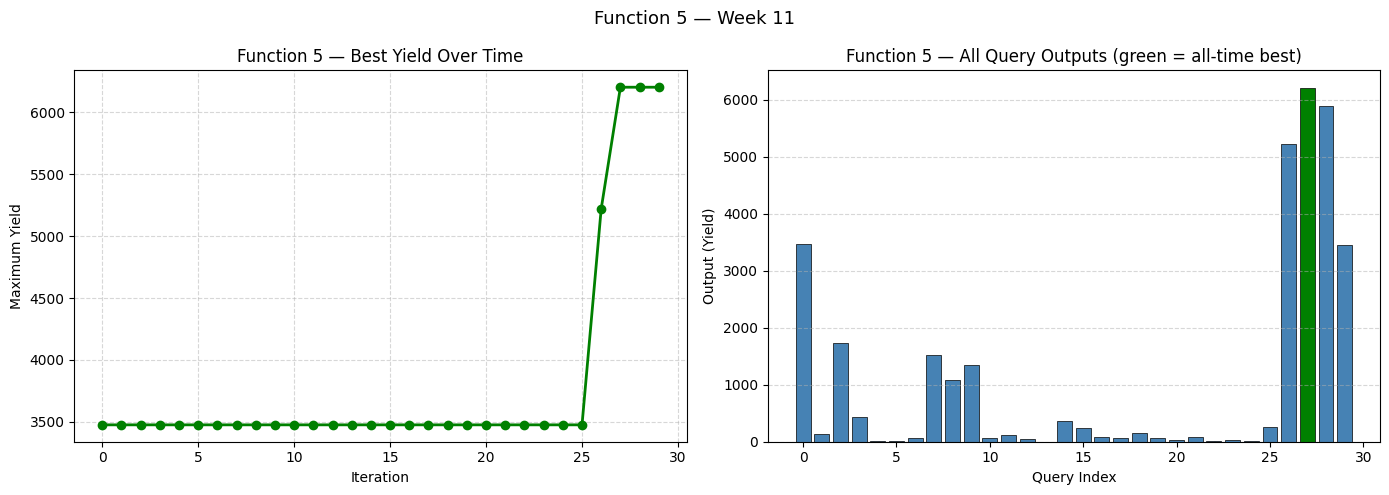

In [6]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(running_max, marker='o', color='green', linewidth=2)
axes[0].set_title('Function 5 — Best Yield Over Time')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Maximum Yield')
axes[0].grid(True, linestyle='--', alpha=0.5)

colors = ['green' if y == np.max(Y_updated) else 'steelblue' for y in Y_updated]
axes[1].bar(range(len(Y_updated)), Y_updated, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Function 5 — All Query Outputs (green = all-time best)')
axes[1].set_xlabel('Query Index')
axes[1].set_ylabel('Output (Yield)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 5 — Week 11', fontsize=13)
plt.tight_layout()
plt.show()